In [2]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
from textblob import TextBlob 
import time
import pytz
from pytrends.request import TrendReq
from pytrends.exceptions import TooManyRequestsError

# Configurable variables
asset = 'MSFT'
company_name = 'Microsoft'
FETCH_GOOGLE_TRENDS = False  # Set to False to skip Google Trends pulling
custom_start_date = None
API_KEY = "sMbDQrZtgGTCquSeDVhrSq_L6ScIrGKk"
BACKOFF_INTERVAL = 60
MAX_RETRIES = 5

# Timeframes
timeframes = [
    ('1m', 'minute', 1), ('5m', 'minute', 5), ('15m', 'minute', 15),
    ('30m', 'minute', 30), ('1h', 'hour', 1), ('4h', 'hour', 4),
    ('1d', 'day', 1), ('1w', 'week', 1)
]

eastern = pytz.timezone('America/New_York')

# Helper for retrying API requests
def get_with_retry(url, params):
    resp = requests.get(url, params=params)
    if resp.status_code == 429:
        time.sleep(BACKOFF_INTERVAL)
        resp = requests.get(url, params=params)
    resp.raise_for_status()
    return resp

# Generate 80-day chunks for Google Trends
def get_chunks(start_date, end_date):
    chunks = []
    current = start_date
    while current < end_date:
        next_chunk = min(current + timedelta(days=80), end_date)
        chunks.append((current, next_chunk))
        current = next_chunk
    return chunks

# Google Trends chunk pull with exponential backoff
def fetch_trends_in_chunks(keyword, start_date, end_date, geo='US', retries=MAX_RETRIES):
    pytrends = TrendReq(hl='en-US', tz=360)
    all_data = []
    chunks = get_chunks(start_date, end_date)

    for start, end in chunks:
        tf_str = f"{start.strftime('%Y-%m-%d')} {end.strftime('%Y-%m-%d')}"
        for attempt in range(retries):
            try:
                pytrends.build_payload([keyword], cat=0, timeframe=tf_str, geo=geo)
                df = pytrends.interest_over_time()
                if not df.empty:
                    df = df[[keyword]].reset_index()
                    df.rename(columns={keyword: 'search_volume'}, inplace=True)
                    df['date'] = df['date'].dt.date
                    all_data.append(df)
                    print(f"✅ Pulled Google Trends for chunk: {tf_str}", flush=True)
                    break
                else:
                    print(f"⚠️ Empty result for {tf_str}, retrying...", flush=True)
            except Exception as e:
                wait_time = 60 * (2 ** attempt)
                print(f"⏳ Retry {attempt+1} for {tf_str} due to error: {e} (waiting {wait_time}s)", flush=True)
                time.sleep(wait_time)
        else:
            print(f"❌ Failed to fetch Google Trends data for {tf_str} after {retries} retries.", flush=True)

    if all_data:
        print("✅ Google search volume has been successfully pulled and will be merged into CSVs.", flush=True)
        return pd.concat(all_data, ignore_index=True)
    else:
        return pd.DataFrame(columns=['date', 'search_volume'])

# Fetch corporate actions
def fetch_corporate_actions(ticker, start_date):
    actions = pd.DataFrame()
    types = ['splits', 'dividends']
    for action_type in types:
        endpoint = f"https://api.polygon.io/v3/reference/{action_type}"
        params = {"ticker": ticker, "apiKey": API_KEY, "limit": 1000}
        resp = get_with_retry(endpoint, params)
        data = resp.json().get('results', [])
        if data:
            df = pd.DataFrame(data)
            if action_type == 'splits':
                df['event_date'] = pd.to_datetime(df['execution_date']).dt.date
                df = df[['event_date', 'split_from', 'split_to']]
                df['split_ratio'] = df['split_to'] / df['split_from']
            elif action_type == 'dividends':
                df['event_date'] = pd.to_datetime(df['ex_dividend_date']).dt.date
                df = df[['event_date', 'cash_amount']]
            elif action_type == 'corporate_actions':
                df['event_date'] = pd.to_datetime(df['event_date']).dt.date
                df = df[['event_date', 'action_type']]
            actions = pd.merge(actions, df, how='outer', on='event_date') if not actions.empty else df
    return actions.rename(columns={'event_date': 'date'})

def fetch_timeframe(ticker, label, span, multiplier, start_str, news_agg_df=None, search_trends_df=None, corp_actions_df=None):
    print(f"Fetching {label} data...", flush=True)
    start_dt = pd.to_datetime(start_str).tz_localize(eastern).astimezone(pytz.UTC)
    start_ms = int(start_dt.timestamp() * 1000)
    limit = 50000
    all_rows = []

    # Define end timestamp
    if label == '1w':
        end_dt = datetime.now(eastern) - timedelta(days=datetime.now(eastern).weekday() + 1)
        end_dt = end_dt.replace(hour=0, minute=0, second=0, microsecond=0)
    else:
        end_dt = datetime.combine(datetime.now(eastern).date() - timedelta(days=1), datetime.max.time())
    end_dt = eastern.localize(end_dt) if end_dt.tzinfo is None else end_dt
    end_ts_utc = int(end_dt.astimezone(pytz.UTC).timestamp() * 1000)

    print(f"End timestamp cutoff for {label}: {end_dt} Eastern / {end_ts_utc} UTC ms", flush=True)

    while start_ms < end_ts_utc:
        url = f"https://api.polygon.io/v2/aggs/ticker/{ticker}/range/{multiplier}/{span}/{start_ms}/{end_ts_utc}"
        params = {"adjusted": "true", "sort": "asc", "limit": limit, "apiKey": API_KEY}
        resp = get_with_retry(url, params)
        rows = resp.json().get('results', [])
        if not rows:
            print(f" No new rows received for {label}. Moving to next interval.", flush=True)
            break
        all_rows.extend(rows)
        last_ts = rows[-1]['t']
        print(f" Pulled {len(rows)} rows, last timestamp: {last_ts} (ms)", flush=True)

        if last_ts >= end_ts_utc:
            print(f"✅ Reached end timestamp cutoff for {label}.", flush=True)
            break

        next_start_ms = last_ts + 1
        if next_start_ms <= start_ms:
            print(f"⚠️ No progress detected (start_ms stuck). Exiting to prevent infinite loop.", flush=True)
            break
        start_ms = next_start_ms
        time.sleep(0.2)

    if not all_rows:
        print(f" No data collected for {label}", flush=True)
        return None

    df = pd.DataFrame(all_rows)
    df['timestamp'] = pd.to_datetime(df['t'], unit='ms', utc=True).dt.tz_convert(eastern)
    suffix = f"_{label}"
    df = df.rename(columns={
        'o': 'open'+suffix, 'h': 'high'+suffix, 'l': 'low'+suffix, 'c': 'close'+suffix,
        'v': 'volume'+suffix, 'n': 'transactions'+suffix
    })
    close = 'close'+suffix
    df['sma20'+suffix] = df[close].rolling(20).mean()
    df['sma50'+suffix] = df[close].rolling(50).mean()
    delta = df[close].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = gain.rolling(14).mean() / loss.rolling(14).mean()
    df['rsi14'+suffix] = 100 - (100 / (1 + rs))
    ema12 = df[close].ewm(span=12, adjust=False).mean()
    ema26 = df[close].ewm(span=26, adjust=False).mean()
    df['macd'+suffix] = ema12 - ema26
    df['macd_signal'+suffix] = df['macd'+suffix].ewm(span=9, adjust=False).mean()
    df['macd_hist'+suffix] = df['macd'+suffix] - df['macd_signal'+suffix]
    bb_mid = df['sma20'+suffix]
    bb_std = df[close].rolling(20).std()
    df['bb_upper'+suffix] = bb_mid + 2 * bb_std
    df['bb_lower'+suffix] = bb_mid - 2 * bb_std
    df['prev_close'+suffix] = df[close].shift(1)
    tr1 = df['high'+suffix] - df['low'+suffix]
    tr2 = (df['high'+suffix] - df['prev_close'+suffix]).abs()
    tr3 = (df['low'+suffix] - df['prev_close'+suffix]).abs()
    df['tr'+suffix] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['atr14'+suffix] = df['tr'+suffix].rolling(14).mean()
    df['obv'+suffix] = (np.sign(df[close].diff()) * df['volume'+suffix]).fillna(0).cumsum()

    df['date'] = df['timestamp'].dt.date
    if news_agg_df is not None and not news_agg_df.empty:
        df = df.merge(news_agg_df, on='date', how='left')
        df[['news_count','avg_sentiment']] = df[['news_count','avg_sentiment']].fillna(0)
    if search_trends_df is not None and not search_trends_df.empty:
        df = df.merge(search_trends_df, on='date', how='left')
        df['search_volume'] = df['search_volume'].fillna(0)
    if corp_actions_df is not None and not corp_actions_df.empty:
        df = df.merge(corp_actions_df, on='date', how='left')

    df.drop(columns=['date'], inplace=True)

    df = df.sort_values('timestamp').drop_duplicates(subset='timestamp', keep='first')
    df.to_csv(f"data_{label}.csv", index=False)
    print(f"✅ Saved data_{label}.csv with {len(df)} rows", flush=True)
    return df

# === Main Execution ===
now = datetime.now(eastern)
price_data_start_date = pd.to_datetime(custom_start_date).date() if custom_start_date else (now - timedelta(days=730)).date()
trends_data_start_date = datetime.now().date() - timedelta(days=80)
start = price_data_start_date.isoformat()
print(f"Starting data fetch for {asset} from {start} to now (Eastern Time)\n", flush=True)

print("Fetching news...", flush=True)
resp = get_with_retry("https://api.polygon.io/v2/reference/news", {"ticker": asset, "limit": 500, "apiKey": API_KEY})
news_df = pd.DataFrame(resp.json().get('results', []))
agg_news_df = pd.DataFrame()
if not news_df.empty:
    news_df['published_utc'] = pd.to_datetime(news_df['published_utc'], utc=True).dt.tz_convert(eastern)
    news_df['date'] = news_df['published_utc'].dt.date
    news_df['sentiment'] = news_df['title'].apply(lambda t: TextBlob(t).sentiment.polarity)
    agg_news_df = news_df.groupby('date').agg(news_count=('sentiment','count'), avg_sentiment=('sentiment','mean')).reset_index()

search_trends_df = pd.DataFrame()
if FETCH_GOOGLE_TRENDS:
    print("Fetching Google Trends search volume...\n", flush=True)
    search_trends_df = fetch_trends_in_chunks(company_name, trends_data_start_date, datetime.now().date() - timedelta(days=1))

corp_actions_df = fetch_corporate_actions(asset, price_data_start_date)

for label, span, mult in timeframes:
    fetch_timeframe(asset, label, span, mult, start, news_agg_df=agg_news_df, search_trends_df=search_trends_df, corp_actions_df=corp_actions_df)


Starting data fetch for MSFT from 2023-05-30 to now (Eastern Time)

Fetching news...
Fetching Google Trends search volume...

✅ Pulled Google Trends for chunk: 2025-03-10 2025-05-28
✅ Google search volume has been successfully pulled and will be merged into CSVs.
Fetching 1m data...
End timestamp cutoff for 1m: 2025-05-28 23:59:59.999999-04:00 Eastern / 1748491199999 UTC ms
 Pulled 50000 rows, last timestamp: 1695319020000 (ms)
 Pulled 50000 rows, last timestamp: 1705512180000 (ms)
 Pulled 50000 rows, last timestamp: 1715259060000 (ms)
 Pulled 50000 rows, last timestamp: 1725898320000 (ms)
 Pulled 50000 rows, last timestamp: 1736354460000 (ms)
 Pulled 50000 rows, last timestamp: 1746128100000 (ms)
 Pulled 10903 rows, last timestamp: 1748476740000 (ms)
 Pulled 1 rows, last timestamp: 1748476740000 (ms)
⚠️ No progress detected (start_ms stuck). Exiting to prevent infinite loop.
✅ Saved data_1m.csv with 310897 rows
Fetching 5m data...
End timestamp cutoff for 5m: 2025-05-28 23:59:59.99999


--- 5M MODEL ---
Creating targets...
Features used: 27

Fold 1/5 — training & tuning...
Storing predictions...

Fold 2/5 — training & tuning...
Storing predictions...

Fold 3/5 — training & tuning...
Storing predictions...

Fold 4/5 — training & tuning...
Storing predictions...

Fold 5/5 — training & tuning...
Storing predictions...
[5M] MAE: 5.2082, RMSE: 9.7904
Reg Accuracy: 98.73%, Bin Accuracy: 51.11%
Reg Directional Accuracy (5m): 100.00% from 69545 tests (69545 rows)
Reg Directional Accuracy (1h): 66.03% from 6655 tests (69545 rows)
Reg Directional Accuracy (4h): 66.03% from 6655 tests (69545 rows)
Reg Directional Accuracy (1d): 75.66% from 456 tests (69545 rows)
Reg Directional Accuracy (1w): 78.41% from 88 tests (69545 rows)
Reg Directional Accuracy (1m): 90.48% from 21 tests (69545 rows)


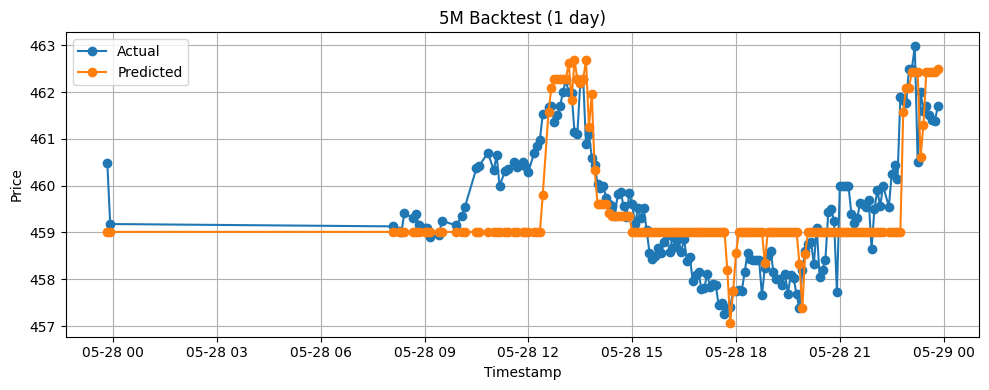

Final capital for 5M: $433.78
Win rate: 65.61% (5144 winners, 2696 losers out of 7840 trades)


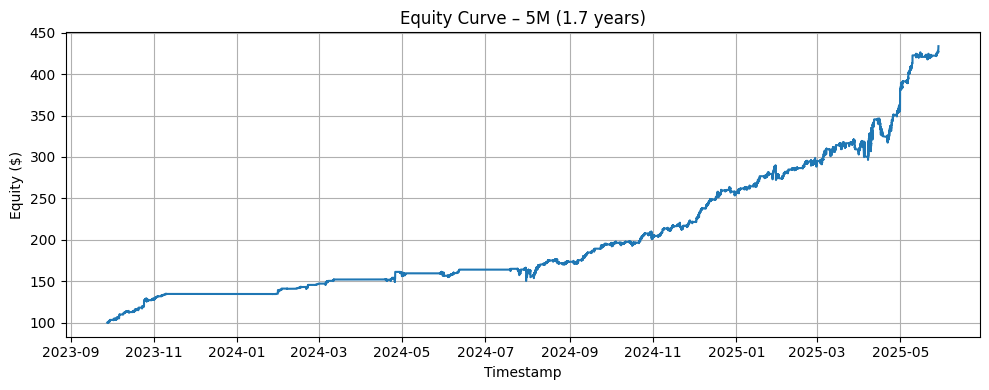

Generating today's predictions...


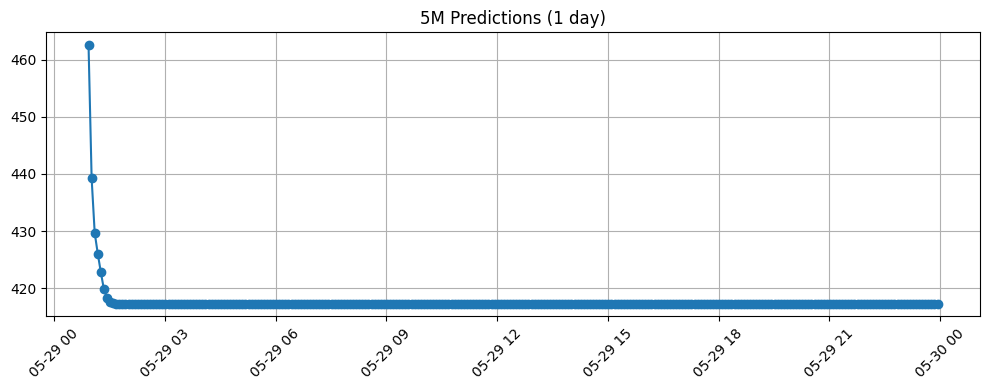


--- 1H MODEL ---
Creating targets...
Features used: 27

Fold 1/5 — training & tuning...
Storing predictions...

Fold 2/5 — training & tuning...
Storing predictions...

Fold 3/5 — training & tuning...
Storing predictions...

Fold 4/5 — training & tuning...
Storing predictions...

Fold 5/5 — training & tuning...
Storing predictions...
[1H] MAE: 6.7109, RMSE: 11.4309
Reg Accuracy: 98.36%, Bin Accuracy: 52.59%
Reg Directional Accuracy (5m): 100.00% from 6655 tests (6655 rows)
Reg Directional Accuracy (1h): 100.00% from 6655 tests (6655 rows)
Reg Directional Accuracy (4h): 100.00% from 6655 tests (6655 rows)
Reg Directional Accuracy (1d): 73.03% from 456 tests (6655 rows)
Reg Directional Accuracy (1w): 85.23% from 88 tests (6655 rows)
Reg Directional Accuracy (1m): 95.24% from 21 tests (6655 rows)


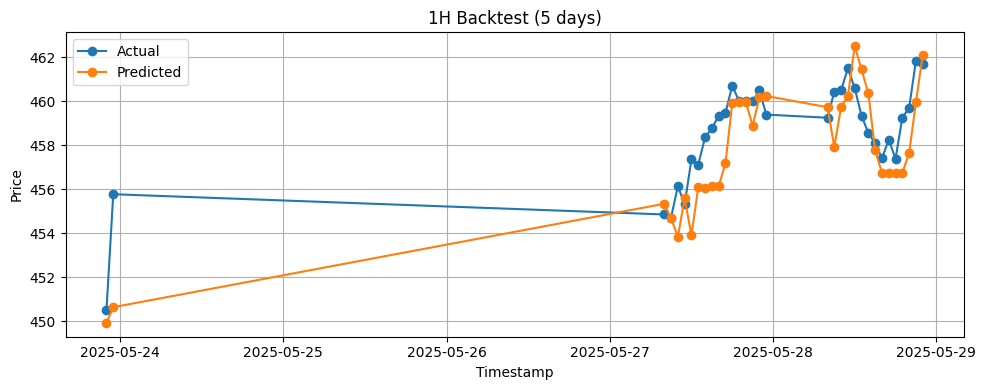

Final capital for 1H: $126.24
Win rate: 66.29% (529 winners, 269 losers out of 798 trades)


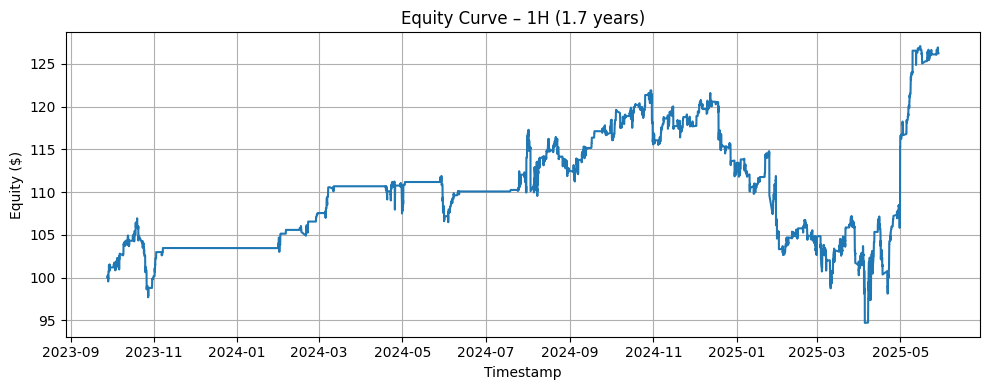

Generating today's predictions...


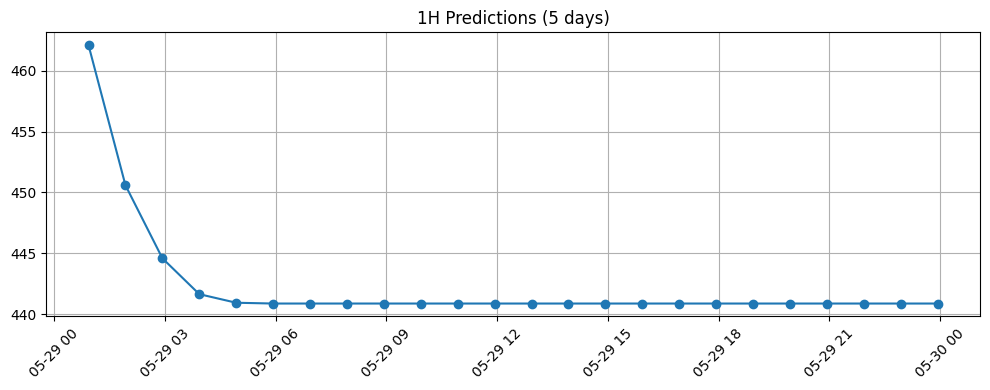


--- 4H MODEL ---
Creating targets...
Features used: 27

Fold 1/5 — training & tuning...
Storing predictions...

Fold 2/5 — training & tuning...
Storing predictions...

Fold 3/5 — training & tuning...
Storing predictions...

Fold 4/5 — training & tuning...
Storing predictions...

Fold 5/5 — training & tuning...
Storing predictions...
[4H] MAE: 8.5492, RMSE: 13.1696
Reg Accuracy: 97.88%, Bin Accuracy: 53.13%
Reg Directional Accuracy (5m): 100.00% from 1805 tests (1805 rows)
Reg Directional Accuracy (1h): 100.00% from 1805 tests (1805 rows)
Reg Directional Accuracy (4h): 100.00% from 1805 tests (1805 rows)
Reg Directional Accuracy (1d): 65.40% from 448 tests (1805 rows)
Reg Directional Accuracy (1w): 80.46% from 87 tests (1805 rows)
Reg Directional Accuracy (1m): 95.00% from 20 tests (1805 rows)


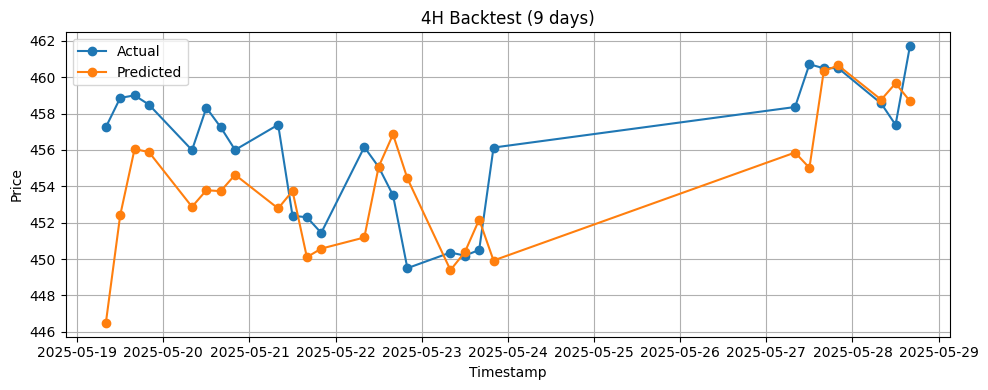

Final capital for 4H: $112.18
Win rate: 63.30% (119 winners, 69 losers out of 188 trades)


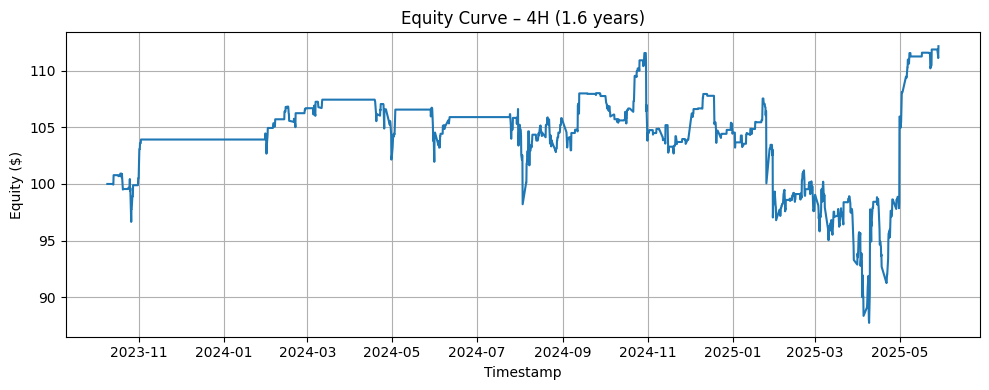

Generating today's predictions...


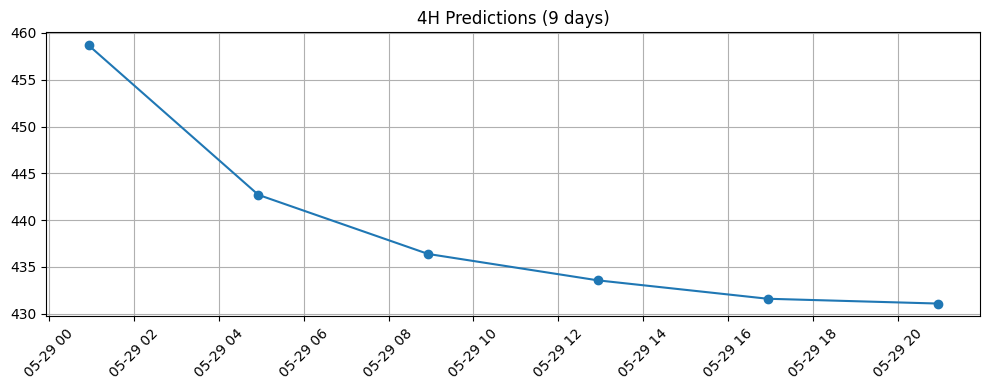


--- 1D MODEL ---
Creating targets...
Features used: 27

Fold 1/5 — training & tuning...
Storing predictions...

Fold 2/5 — training & tuning...
Storing predictions...

Fold 3/5 — training & tuning...
Storing predictions...

Fold 4/5 — training & tuning...
Storing predictions...

Fold 5/5 — training & tuning...
Storing predictions...
[1D] MAE: 11.8063, RMSE: 17.0698
Reg Accuracy: 97.07%, Bin Accuracy: 56.39%
Reg Directional Accuracy (5m): 100.00% from 415 tests (415 rows)
Reg Directional Accuracy (1h): 100.00% from 415 tests (415 rows)
Reg Directional Accuracy (4h): 100.00% from 415 tests (415 rows)
Reg Directional Accuracy (1d): 100.00% from 415 tests (415 rows)
Reg Directional Accuracy (1w): 64.77% from 88 tests (415 rows)
Reg Directional Accuracy (1m): 90.48% from 21 tests (415 rows)


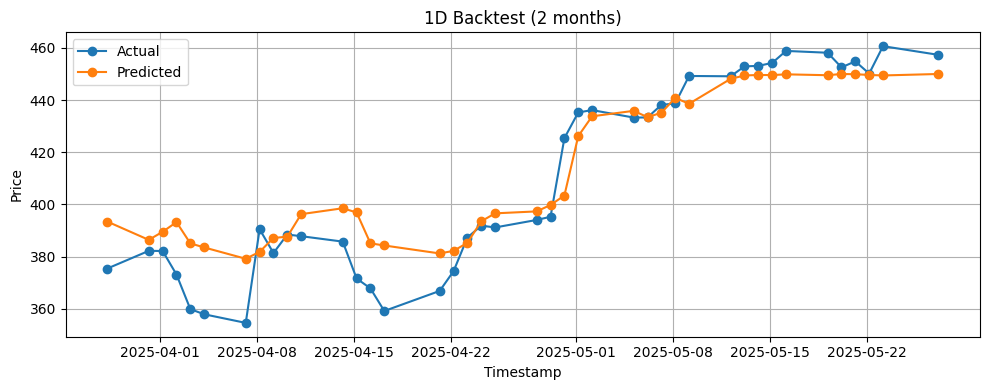

Final capital for 1D: $142.07
Win rate: 75.44% (43 winners, 14 losers out of 57 trades)


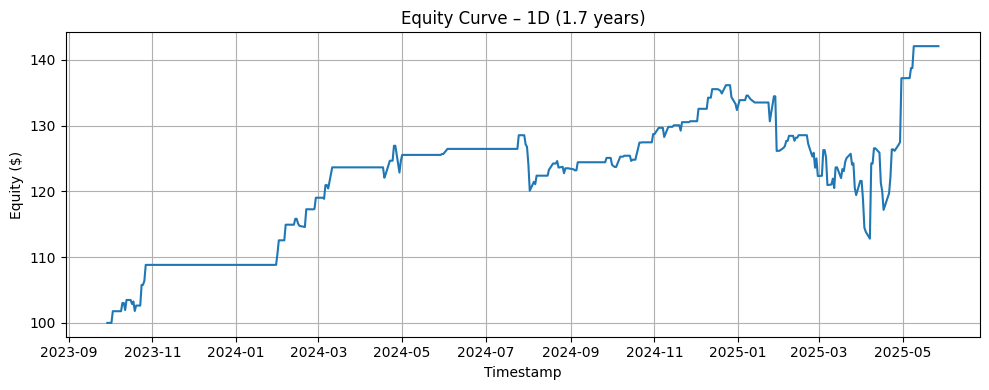

Generating today's predictions...


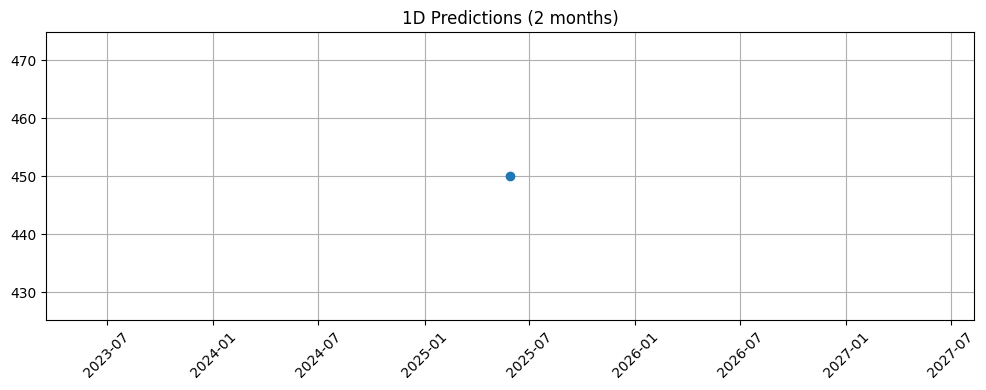


--- 1W MODEL ---
Creating targets...
Features used: 27

Fold 1/5 — training & tuning...
Storing predictions...

Fold 2/5 — training & tuning...
Storing predictions...

Fold 3/5 — training & tuning...
Storing predictions...

Fold 4/5 — training & tuning...
Storing predictions...

Fold 5/5 — training & tuning...
Storing predictions...
[1W] MAE: 21.4996, RMSE: 29.2071
Reg Accuracy: 94.69%, Bin Accuracy: 58.82%
Reg Directional Accuracy (5m): 100.00% from 85 tests (85 rows)
Reg Directional Accuracy (1h): 100.00% from 85 tests (85 rows)
Reg Directional Accuracy (4h): 100.00% from 85 tests (85 rows)
Reg Directional Accuracy (1d): 100.00% from 85 tests (85 rows)
Reg Directional Accuracy (1w): 100.00% from 85 tests (85 rows)
Reg Directional Accuracy (1m): 60.00% from 20 tests (85 rows)


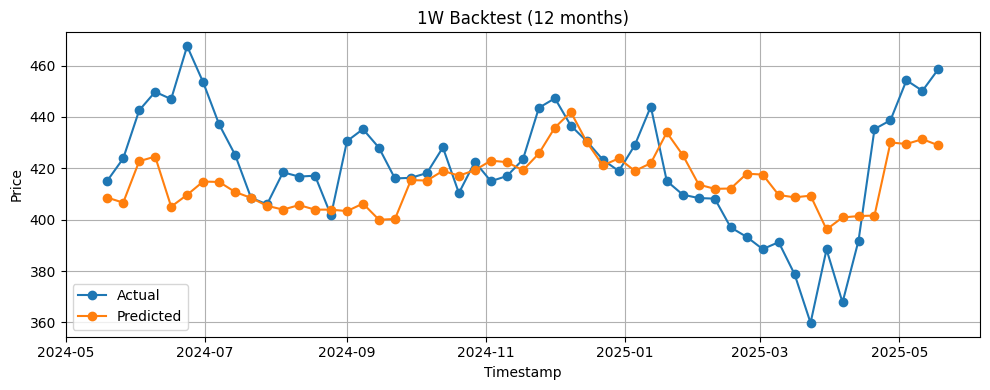

Final capital for 1W: $128.17
Win rate: 80.00% (8 winners, 2 losers out of 10 trades)


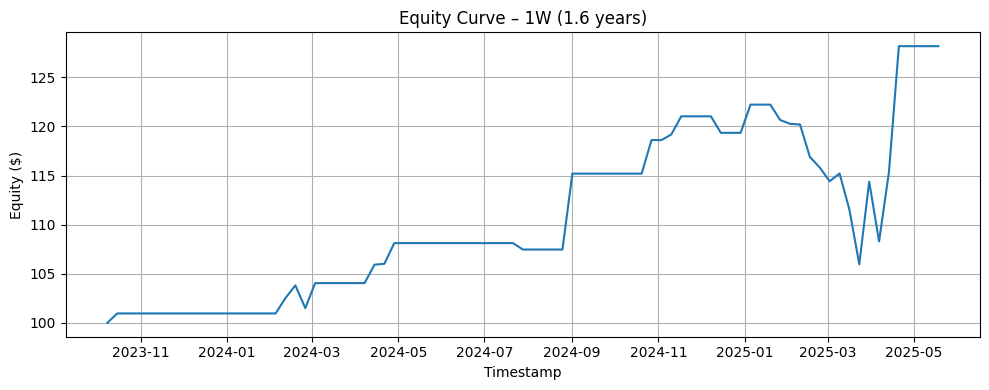

Generating today's predictions...


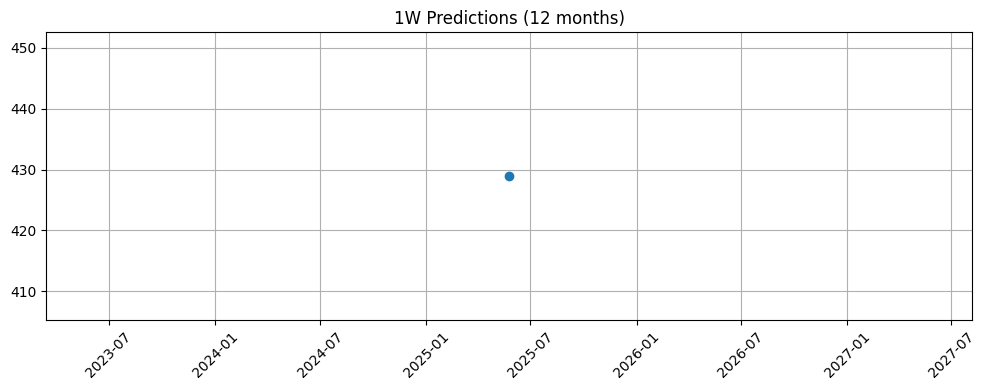

In [6]:
, utc=True).dt.tz_convert(eastern)
    df.sort_values('timestamp', inplace=True)

    # Create targets
    print("Creating targets...")
    df['target_reg'] = df[f'close_{freq_label}'].shift(-1)
    df['target_bin'] = (df[f'close_{freq_label}'].shift(-1) > df[f'close_{freq_label}']).astype(int)
    df.dropna(subset=['target_reg','target_bin'], inplace=True)

    # Feature list
    features = [c for c in df.columns if c not in ['timestamp','target_reg','target_bin']]
    print(f"Features used: {len(features)}")

    # Walk-forward TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)
    all_preds_reg, all_trues_reg = [], []
    all_preds_bin, all_trues_bin = [], []
    all_times = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df[features])):
        print(f"\nFold {fold+1}/5 — training & tuning...")
        # Split data
        X_train_full = df.iloc[train_idx][features].values
        X_test = df.iloc[test_idx][features].values
        y_train_reg_full = df.iloc[train_idx]['target_reg'].values
        y_test_reg = df.iloc[test_idx]['target_reg'].values
        y_train_bin_full = df.iloc[train_idx]['target_bin'].values
        y_test_bin = df.iloc[test_idx]['target_bin'].values

        # Validation split for early stopping
        val_size = int(len(X_train_full) * 0.2)
        X_sub, X_val = X_train_full[val_size:], X_train_full[:val_size]
        y_sub_reg, y_val_reg = y_train_reg_full[val_size:], y_train_reg_full[:val_size]
        y_sub_bin, y_val_bin = y_train_bin_full[val_size:], y_train_bin_full[:val_size]

        # Feature selection
        sel_reg = SelectFromModel(XGBRegressor(tree_method='hist', random_state=42), threshold='median')
        sel_reg.fit(X_sub, y_sub_reg)
        sel_clf = SelectFromModel(XGBClassifier(eval_metric='logloss', tree_method='hist', random_state=42), threshold='median')
        sel_clf.fit(X_sub, y_sub_bin)

                # Regression objective function
        def objective_reg(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
                'gamma': trial.suggest_float('gamma', 0.0, 5.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
                'tree_method': 'hist',
                'random_state': 42,
                'objective': 'reg:squarederror'
            }
            model = XGBRegressor(**params)
            # Simple fit without unsupported arguments
            model.fit(sel_reg.transform(X_sub), y_sub_reg)
            preds = model.predict(sel_reg.transform(X_test))
            return mean_absolute_error(y_test_reg, preds)

        # Create and run regression study
        study_reg = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=42),
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
        study_reg.optimize(objective_reg, n_trials=200)
        reg_cv = XGBRegressor(**study_reg.best_params, tree_method='hist', random_state=42)
        reg_cv.fit(sel_reg.transform(X_train_full), y_train_reg_full)

                # Classification objective function
        def objective_clf(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
                'gamma': trial.suggest_float('gamma', 0.0, 5.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
                'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),
                'tree_method': 'hist',
                'random_state': 42,
                'eval_metric': 'logloss'
            }
            model = XGBClassifier(**params)
            # Simple fit without unsupported arguments
            model.fit(sel_clf.transform(X_sub), y_sub_bin)
            preds = model.predict(sel_clf.transform(X_test))
            return 1 - accuracy_score(y_test_bin, preds)

        # Create and run classification study
        study_clf = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=42),
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
        study_clf.optimize(objective_clf, n_trials=100)
        clf_cv = XGBClassifier(**study_clf.best_params, tree_method='hist', random_state=42)
        clf_cv.fit(sel_clf.transform(X_train_full), y_train_bin_full)

        print("Storing predictions...")
        # Collect predictions
        all_preds_reg.extend(reg_cv.predict(sel_reg.transform(X_test)))
        all_trues_reg.extend(y_test_reg)
        all_preds_bin.extend(clf_cv.predict(sel_clf.transform(X_test)))
        all_trues_bin.extend(y_test_bin)
        all_times.extend(df.iloc[test_idx]['timestamp'].values)

    # Final metrics
    mae = mean_absolute_error(all_trues_reg, all_preds_reg)
    rmse = np.sqrt(mean_squared_error(all_trues_reg, all_preds_reg))
    reg_acc = 100 - np.mean(np.abs((np.array(all_trues_reg)-np.array(all_preds_reg))/(np.array(all_trues_reg)+1e-8))) * 100
    bin_acc = accuracy_score(all_trues_bin, all_preds_bin) * 100
    print(f"[{freq_label.upper()}] MAE: {mae:.4f}, RMSE: {rmse:.4f}")

    print(f"Reg Accuracy: {reg_acc:.2f}%, Bin Accuracy: {bin_acc:.2f}%")

    # Build evaluation DataFrame
        # Build evaluation DataFrame, preserving timezone
    df_eval = pd.DataFrame({
        'timestamp': all_times,
        'actual': all_trues_reg,
        'predicted': all_preds_reg
    })
    # timestamp column already tz-aware
    df_eval['date'] = df_eval['timestamp'].dt.date
    df_eval['date'] = df_eval['timestamp'].dt.date

    # Directional accuracy function
    def directional_accuracy(period, label):
        period_map = {'5min':'5min','h':'h','4h':'4h','d':'d','w-mon':'W-MON','m':'M'}
        code = period_map.get(period.lower(), period.lower())
        df_eval['period'] = df_eval['timestamp'].dt.to_period(code)
        gp = df_eval.groupby('period')[['actual','predicted']].agg(['first','last'])
        actual_dir = (gp['actual']['last'] > gp['actual']['first']).astype(int)
        pred_dir = (gp['predicted']['last'] > gp['predicted']['first']).astype(int)
        print(f"Reg Directional Accuracy ({label}): {(actual_dir==pred_dir).mean()*100:.2f}% from {len(actual_dir)} tests ({len(df_eval)} rows)")

    directional_accuracy('5min','5m')
    directional_accuracy('h','1h')
    directional_accuracy('4h','4h')
    directional_accuracy('d','1d')
    directional_accuracy('w-mon','1w')
    directional_accuracy('m','1m')

            # Plot backtest series
    df_bt = df_eval.set_index('timestamp')
    # Use df_bt index for cutoff to keep timezone consistency
    if freq_label == '1w':
        cutoff = df_bt.index.max() - pd.Timedelta(days=365)
    else:
        cutoff = df_bt.index.max() - pd.Timedelta(days=plot_days)
    df_plot = df_bt[df_bt.index >= cutoff]

    # Compute span label
    span = df_plot.index.max() - df_plot.index.min()
    days = span.days
    if days == 1:
        span_label = '1 day'
    elif days < 30:
        span_label = f"{days} days"
    elif days < 365:
        span_label = f"{round(days/30)} months"
    else:
        span_label = f"{round(days/365,1)} years"

    plt.figure(figsize=(10,4))
    plt.plot(df_plot['actual'], marker='o', label='Actual')
    plt.plot(df_plot['predicted'], marker='o', label='Predicted')
    plt.title(f"{freq_label.upper()} Backtest ({span_label})")
    plt.xlabel('Timestamp')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Equity backtest and win rate
    df_equity = simulate_trading(df_eval)
    final_cap = df_equity['equity'].iloc[-1]
    print(f"Final capital for {freq_label.upper()}: ${final_cap:.2f}")

    in_position = False
    entry_price = 0.0
    wins = 0
    losses = 0
    total_trades = 0
    for _, row in df_eval.iterrows():
        price = row['actual']
        pred = row['predicted']
        if pred > price and not in_position:
            entry_price = price
            in_position = True
        elif pred < price and in_position:
            exit_price = price
            in_position = False
            total_trades += 1
            if exit_price > entry_price:
                wins += 1
            else:
                losses += 1
    win_rate = (wins / total_trades * 100) if total_trades > 0 else 0.0
    print(f"Win rate: {win_rate:.2f}% ({wins} winners, {losses} losers out of {total_trades} trades)")

    # Equity curve plot
    eq_span = df_equity['timestamp'].max() - df_equity['timestamp'].min()
    eq_days = eq_span.days
    if eq_days == 1:
        eq_label = '1 day'
    elif eq_days < 30:
        eq_label = f"{eq_days} days"
    elif eq_days < 365:
        eq_label = f"{round(eq_days/30)} months"
    else:
        eq_label = f"{round(eq_days/365,1)} years"

    plt.figure(figsize=(10,4))
    plt.plot(df_equity['timestamp'], df_equity['equity'], label='Equity')
    plt.title(f"Equity Curve – {freq_label.upper()} ({eq_label})")
    plt.xlabel('Timestamp')
    plt.ylabel('Equity ($)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Today's predictions
    print("Generating today's predictions...")
    now_eastern = datetime.now(pytz.utc).astimezone(eastern)
    last_ts = df['timestamp'].max()
    if freq_label == '1w':
        times = pd.DatetimeIndex([last_ts + pd.Timedelta(weeks=1)])
    else:
        start = datetime.combine(now_eastern.date(), time.min).replace(tzinfo=eastern)
        end = datetime.combine(now_eastern.date(), time.max).replace(hour=23, minute=0, second=0, microsecond=0, tzinfo=eastern)
        freq_map = {'5m':'5min','1h':'h','4h':'4h','1d':'d'}
        times = pd.date_range(start=start, end=end, freq=freq_map.get(freq_label,'h'), tz=eastern)

    pred_list = []
    tmp = df.copy()
    for ts in times:
        ts_naive = ts.tz_localize(None)
        last_close = tmp[f'close_{freq_label}'].iloc[-1]
        feat = tmp.iloc[-1][features].copy()
        feat[f'close_{freq_label}'] = last_close
        Xf = feat.values.reshape(1, -1)
        pr = reg_cv.predict(sel_reg.transform(Xf))[0]
        pd_dir = clf_cv.predict(sel_clf.transform(Xf))[0]
        pred_list.append({'timestamp': ts_naive, 'predicted_price': pr, 'predicted_direction': pd_dir})
        tmp = pd.concat([tmp, pd.DataFrame([{'timestamp': ts_naive, f'close_{freq_label}': pr}])], ignore_index=True)

    df_pred = pd.DataFrame(pred_list)
    df_pred.to_csv(f'predictions_{freq_label}.csv', index=False)

    if not df_pred.empty:
        plt.figure(figsize=(10,4))
        plt.plot(df_pred['timestamp'], df_pred['predicted_price'], marker='o')
        plt.title(f"{freq_label.upper()} Predictions ({span_label})")
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    elif freq_label == '1w':
        print(f"[WARN] No predictions generated for {freq_label.upper()} — check data availability.")

# Run daily first, then others
run_model('data_5m.csv','5m',1)
run_model('data_15m.csv','15m',3)
run_model('data_1h.csv','1h',5)
run_model('data_4h.csv','4h',10) 
run_model('data_1d.csv','1d',60)
run_model('data_1w.csv','1w',365) 
